# Ноутбук 2 — Усечённое сингулярное разложение (Truncated SVD)

Продолжение работы с датасетом **Ames Housing** (De Cock, 2011). Данные уже подготовлены
в ноутбуке `01_PCA_demo.ipynb`; здесь мы их только загружаем.

### Зачем нужен отдельный метод

Ноутбук 1 закончился на конкретном ограничении PCA: **он обязан центрировать данные**.
Для плотной матрицы 2927 × 67 это не проблема. Но 21 категориальный признак после one-hot
кодирования даёт матрицу с плотностью ~11%, а в реальных задачах (тексты, логи кликов,
рекомендательные системы) плотность бывает 0.01% и ниже. Вычитание среднего из такой матрицы
превращает каждый ноль в $-\mu_j$ — разреженность исчезает, и объект, занимавший мегабайты,
начинает занимать гигабайты.

**Truncated SVD** решает ровно эту задачу: он вычисляет то же самое усечённое сингулярное
разложение, но **не центрируя** матрицу, и потому работает с разреженным представлением напрямую.

### План

1. Загрузка артефактов из ноутбука 1
2. **Теория SVD**: существование, геометрия, связь с собственными значениями
3. **Теорема Эккарта–Янга–Мирского** — почему усечение оптимально
4. Точное соотношение PCA ↔ Truncated SVD (численная проверка)
5. Что центрирование делает с разреженностью
6. Truncated SVD на разреженной one-hot матрице: спектр, интерпретация компонент
7. Численная проверка теоремы Эккарта–Янга
8. Алгоритмы: `randomized` vs `arpack`; демонстрация масштабируемости
9. Практическая проверка: SVD-признаки в регрессии
10. Сводное сравнение PCA и Truncated SVD; сохранение результатов

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib
from scipy import sparse
from scipy.sparse.linalg import svds

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100); pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


## 1. Загрузка подготовленных данных

Всё берём из файлов, записанных первым ноутбуком. Если их нет — надо сначала выполнить
`01_PCA_demo.ipynb` целиком.

In [2]:
REQUIRED = ["data/processed/X_scaled.npy", "data/processed/X_numeric.csv",
            "data/processed/X_categorical.csv", "data/processed/y_target.csv",
            "data/processed/metadata.json", "artifacts/pca.joblib"]
missing = [f for f in REQUIRED if not os.path.exists(f)]
assert not missing, f"Сначала выполните 01_PCA_demo.ipynb. Не хватает: {missing}"

with open("data/processed/metadata.json", encoding="utf-8") as f:
    meta = json.load(f)

X_scaled = np.load("data/processed/X_scaled.npy")                    # числовые, стандартизованные
X_num    = pd.read_csv("data/processed/X_numeric.csv")               # числовые, исходный масштаб
X_cat    = pd.read_csv("data/processed/X_categorical.csv", dtype=str)  # категориальные
y_df     = pd.read_csv("data/processed/y_target.csv")
y        = y_df["SalePrice_log"].values
FEATURES = meta["numeric_features"]

pca_ref  = joblib.load("artifacts/pca.joblib")
scaler   = joblib.load("artifacts/scaler.joblib")

print(f"Датасет            : {meta['dataset']}")
print(f"Строк после очистки: {meta['n_rows_clean']} (из {meta['n_rows_raw']})")
print(f"Числовых признаков : {X_scaled.shape[1]}")
print(f"Категориальных     : {X_cat.shape[1]}")
print(f"PCA из ноутбука 1  : {meta['pca_n_components']} компонент, "
      f"{meta['pca_cum_evr']*100:.1f}% дисперсии")
X_cat.head(3)

Датасет            : Ames Housing (De Cock, 2011)
Строк после очистки: 2927 (из 2930)
Числовых признаков : 67
Категориальных     : 21
PCA из ноутбука 1  : 31 компонент, 90.6% дисперсии


,MSSubClass,MSZoning,LandContour,LotConfig,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,Electrical,GarageType,MiscFeature,SaleType,SaleCondition
0,20,RL,Lvl,Corner,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,Plywood,Stone,CBlock,GasA,SBrkr,Attchd,NaN,WD,Normal
1,20,RH,Lvl,Inside,NAmes,Feedr,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,NaN,CBlock,GasA,SBrkr,Attchd,NaN,WD,Normal
2,20,RL,Lvl,Corner,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,CBlock,GasA,SBrkr,Attchd,Gar2,WD,Normal


---

# 2. Теория: сингулярное разложение

## 2.1 Теорема о существовании

Для **любой** матрицы $A \in \mathbb{R}^{n \times p}$ ранга $r$ существует разложение

$$A \;=\; U \Sigma V^\top, \qquad
U \in \mathbb{R}^{n \times n},\;\; V \in \mathbb{R}^{p \times p} \text{ — ортогональные},$$

где $\Sigma \in \mathbb{R}^{n \times p}$ «диагональна» с элементами
$\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0 = \sigma_{r+1} = \dots$

Это отличает SVD от спектрального разложения: последнее требует квадратной (и, для ортогональной
диагонализации, симметричной) матрицы, а SVD существует **всегда**, для прямоугольной,
вырожденной, любой.

В **экономной** форме (`full_matrices=False`) хранятся только первые $r$ столбцов:
$U_r \in \mathbb{R}^{n \times r}$, $\Sigma_r \in \mathbb{R}^{r \times r}$, $V_r \in \mathbb{R}^{p \times r}$.

Эквивалентная запись — сумма матриц ранга 1:

$$A \;=\; \sum_{i=1}^{r} \sigma_i \, u_i v_i^\top .$$

Каждое слагаемое $u_i v_i^\top$ — матрица ранга 1 с единичной нормой Фробениуса, а $\sigma_i$ —
её «вес». Слагаемые ортогональны друг другу в смысле скалярного произведения Фробениуса, поэтому

$$\|A\|_F^2 \;=\; \sum_{i=1}^{r}\sigma_i^2 .$$

## 2.2 Связь с собственными значениями

$$A^\top A = V \Sigma^\top \Sigma V^\top, \qquad A A^\top = U \Sigma \Sigma^\top U^\top .$$

Отсюда сразу:
* $v_i$ (**правые** сингулярные векторы) — собственные векторы $A^\top A$;
* $u_i$ (**левые**) — собственные векторы $A A^\top$;
* $\sigma_i = \sqrt{\lambda_i(A^\top A)}$, и эти $\lambda_i \ge 0$, так как $A^\top A$ неотрицательно определена;
* $A v_i = \sigma_i u_i$ — сингулярные векторы связаны действием самой $A$.

Практически SVD никогда не считают через $A^\top A$: это возводит число обусловленности в
квадрат ($\text{cond}(A^\top A) = \text{cond}(A)^2$) и теряет точность. Используются алгоритмы,
работающие с $A$ напрямую (Golub–Kahan, Lanczos, randomized).

## 2.3 Геометрия

Любое линейное отображение $x \mapsto Ax$ раскладывается в композицию трёх:

$$\underbrace{V^\top}_{\text{поворот}} \;\to\; \underbrace{\Sigma}_{\text{растяжение по осям}} \;\to\; \underbrace{U}_{\text{поворот}}$$

Единичная сфера переходит в эллипсоид с полуосями $\sigma_i$, направленными вдоль $u_i$;
прообразы этих полуосей — векторы $v_i$. $\sigma_1 = \|A\|_2$ — максимальный коэффициент растяжения.

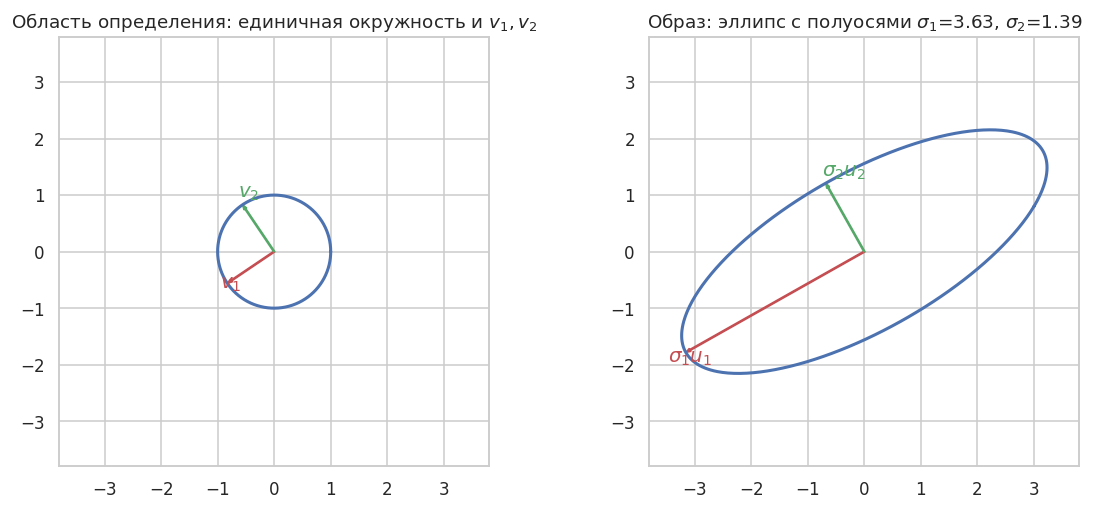

σ = [3.626 1.39 ]
‖A‖₂ = σ₁ = 3.6260   (numpy: 3.6260)
‖A‖_F = √Σσᵢ² = 3.8833   (numpy: 3.8833)
|det A| = Πσᵢ = 5.0400   (numpy: 5.0400)
cond(A) = σ₁/σ₂ = 2.6087


In [3]:
# Геометрия SVD: единичная окружность -> эллипс
A2 = np.array([[3.0, 1.2], [0.8, 2.0]])
U2, s2, V2t = np.linalg.svd(A2)

theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = A2 @ circle

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

axes[0].plot(circle[0], circle[1], color="#4C72B0", lw=2)
for i, c in enumerate(["#C44E52", "#55A868"]):
    v = V2t[i]
    axes[0].arrow(0, 0, v[0], v[1], color=c, width=.02, length_includes_head=True)
    axes[0].text(v[0]*1.15, v[1]*1.15, f"$v_{i+1}$", color=c, fontsize=13)
axes[0].set_title("Область определения: единичная окружность и $v_1, v_2$")
axes[0].set_aspect("equal"); axes[0].set_xlim(-3.8, 3.8); axes[0].set_ylim(-3.8, 3.8)

axes[1].plot(ellipse[0], ellipse[1], color="#4C72B0", lw=2)
for i, c in enumerate(["#C44E52", "#55A868"]):
    u = U2[:, i] * s2[i]
    axes[1].arrow(0, 0, u[0], u[1], color=c, width=.02, length_includes_head=True)
    axes[1].text(u[0]*1.1, u[1]*1.1, f"$\\sigma_{i+1} u_{i+1}$", color=c, fontsize=13)
axes[1].set_title(f"Образ: эллипс с полуосями $\\sigma_1$={s2[0]:.2f}, $\\sigma_2$={s2[1]:.2f}")
axes[1].set_aspect("equal"); axes[1].set_xlim(-3.8, 3.8); axes[1].set_ylim(-3.8, 3.8)

plt.tight_layout(); plt.show()

print(f"σ = {s2.round(3)}")
print(f"‖A‖₂ = σ₁ = {s2[0]:.4f}   (numpy: {np.linalg.norm(A2, 2):.4f})")
print(f"‖A‖_F = √Σσᵢ² = {np.sqrt((s2**2).sum()):.4f}   (numpy: {np.linalg.norm(A2, 'fro'):.4f})")
print(f"|det A| = Πσᵢ = {np.prod(s2):.4f}   (numpy: {abs(np.linalg.det(A2)):.4f})")
print(f"cond(A) = σ₁/σ₂ = {s2[0]/s2[1]:.4f}")

## 3. Усечение и теорема Эккарта–Янга–Мирского

**Усечённое SVD ранга $k$** — это первые $k$ слагаемых суммы:

$$A_k \;=\; \sum_{i=1}^{k}\sigma_i u_i v_i^\top \;=\; U_k \Sigma_k V_k^\top, \qquad k < r .$$

Почему именно первые $k$, а не какие-то другие? Ответ даёт центральная теорема всего метода.

> **Теорема (Eckart–Young 1936, Mirsky 1960).** Для любой матрицы $B$ ранга не выше $k$
> $$\|A - B\|_F \;\ge\; \|A - A_k\|_F = \sqrt{\sum_{i>k}\sigma_i^2},$$
> $$\|A - B\|_2 \;\ge\; \|A - A_k\|_2 = \sigma_{k+1}.$$
> Более того, неравенство верно для **любой унитарно инвариантной нормы**.

То есть $A_k$ — **наилучшее приближение матрицы $A$ матрицей ранга $k$**, и это оптимум не среди
какого-то удобного класса, а среди всех матриц ранга $\le k$ вообще. Оптимум получается
«бесплатно», простым отбрасыванием хвоста разложения.

*Идея доказательства для спектральной нормы.* Пусть $\operatorname{rank}(B) \le k$, тогда
$\dim\ker B \ge p - k$. Подпространство $W = \operatorname{span}(v_1, \dots, v_{k+1})$ имеет
размерность $k+1$; сумма размерностей $(p-k) + (k+1) = p+1 > p$, значит есть ненулевой
$w \in \ker B \cap W$, $\|w\| = 1$. Для него $Bw = 0$ и, так как $w = \sum_{i \le k+1} c_i v_i$,
$$\|A - B\|_2^2 \ge \|(A-B)w\|^2 = \|Aw\|^2 = \sum_{i \le k+1} c_i^2 \sigma_i^2 \ge \sigma_{k+1}^2 . \;\square$$

**Практический смысл.** Сингулярные значения — «шкала важности» направлений. Если спектр быстро
убывает, то $\sqrt{\sum_{i>k}\sigma_i^2}$ мало уже при небольшом $k$, и матрица $n \times p$
заменяется на $U_k, \Sigma_k, V_k$ — это $k(n + p + 1)$ чисел вместо $np$. Именно так работают
сжатие изображений, латентно-семантический анализ и матричная факторизация в рекомендательных системах.

## 4. Точное соотношение PCA ↔ Truncated SVD

Разница между методами — **одна операция**:

| | PCA | Truncated SVD |
|---|---|---|
| Что раскладывается | $X_c = X - \mathbf{1}\mu^\top$ (центрированная) | $A$ **как есть** |
| Разложение | $X_c = U\Sigma V^\top$ | $A = U\Sigma V^\top$ |
| Компоненты | $V$ | $V$ |
| Проекция | $Z = X_c V_k = U_k\Sigma_k$ | $Z = A V_k = U_k \Sigma_k$ |
| Разреженность | разрушается центрированием | **сохраняется** |
| $\lambda_i$ | $\sigma_i^2/(n-1)$ = дисперсия по оси | $\sigma_i^2/(n-1)$ = **второй момент** по оси |

Отсюда строгое утверждение:

$$\boxed{\;\texttt{TruncatedSVD}(X_c) \;\equiv\; \texttt{PCA}(X)\;}$$

Проверим это численно на нашей стандартизованной матрице (она уже центрирована в ноутбуке 1).

In [4]:
from sklearn.decomposition import PCA, TruncatedSVD

K = 10
print(f"Центрирование X_scaled: max|mean| = {np.abs(X_scaled.mean(0)).max():.2e}  -> уже центрирована\n")

pca  = PCA(n_components=K, svd_solver="full", random_state=RANDOM_STATE).fit(X_scaled)
tsvd = TruncatedSVD(n_components=K, algorithm="arpack", random_state=RANDOM_STATE).fit(X_scaled)

cmp = pd.DataFrame({
    "σ (PCA)":  pca.singular_values_.round(4),
    "σ (TSVD)": tsvd.singular_values_.round(4),
    "EVR (PCA)":  pca.explained_variance_ratio_.round(5),
    "EVR (TSVD)": tsvd.explained_variance_ratio_.round(5),
}, index=[f"PC{i+1}" for i in range(K)])

print(f"max|σ_PCA − σ_TSVD|                 = {np.abs(pca.singular_values_ - tsvd.singular_values_).max():.3e}")
print(f"max|EVR_PCA − EVR_TSVD|             = {np.abs(pca.explained_variance_ratio_ - tsvd.explained_variance_ratio_).max():.3e}")
print(f"max| |V_PCA| − |V_TSVD| |           = {np.abs(np.abs(pca.components_) - np.abs(tsvd.components_)).max():.3e}")
print("  (знак сингулярного вектора не определён: (u,v) и (−u,−v) дают то же uσvᵀ)\n")
cmp

Центрирование X_scaled: max|mean| = 6.11e-14  -> уже центрирована

max|σ_PCA − σ_TSVD|                 = 2.416e-13
max|EVR_PCA − EVR_TSVD|             = 2.776e-16
max| |V_PCA| − |V_TSVD| |           = 2.916e-14
  (знак сингулярного вектора не определён: (u,v) и (−u,−v) дают то же uσvᵀ)



,σ (PCA),σ (TSVD),EVR (PCA),EVR (TSVD)
PC1,215.1778,215.1778,0.23610,0.23610
PC2,125.8838,125.8838,0.08081,0.08081
PC3,109.1848,109.1848,0.06079,0.06079
PC4,100.3943,100.3943,0.05139,0.05139
PC5,95.9248,95.9248,0.04692,0.04692
PC6,85.1117,85.1117,0.03694,0.03694
PC7,81.7323,81.7323,0.03406,0.03406
PC8,77.9942,77.9942,0.03102,0.03102
PC9,71.6563,71.6563,0.02618,0.02618
PC10,69.1103,69.1103,0.02435,0.02435


Совпадение до $10^{-13}$. Это не совпадение чисел, а тождество: на центрированных данных методы
**математически одинаковы**. Различие проявляется только тогда, когда центрирование не выполнено —
и именно в этом режиме Truncated SVD полезен.

## 5. Что центрирование делает с разреженностью

Закодируем 21 категориальный признак one-hot и посмотрим, что произойдёт с матрицей при вычитании
средних по столбцам.

Разреженная матрица A : 2927 × 186, ненулевых 61,467, плотность 0.1129
  память CSR          : 0.75 МБ
  память плотная      : 4.36 МБ   (в 5.8 раза больше)

Плотность ПОСЛЕ центрирования: 1.0000  <-- 100%, разреженности больше нет


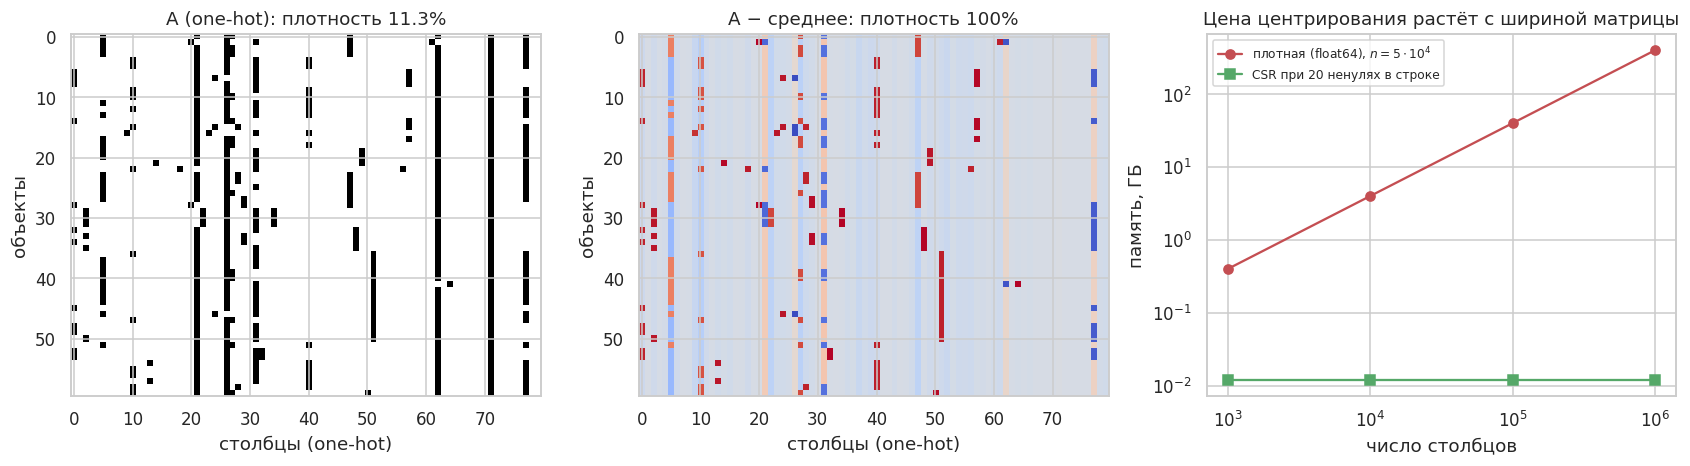

In [5]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
A = ohe.fit_transform(X_cat)                # scipy.sparse.csr_matrix
feat_names = list(ohe.get_feature_names_out(X_cat.columns))

n, m = A.shape
sparse_mb = (A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 1e6
dense_mb  = n * m * 8 / 1e6

A_dense = A.toarray()
A_centered = A_dense - A_dense.mean(axis=0)

print(f"Разреженная матрица A : {n} × {m}, ненулевых {A.nnz:,}, плотность {A.nnz/(n*m):.4f}")
print(f"  память CSR          : {sparse_mb:.2f} МБ")
print(f"  память плотная      : {dense_mb:.2f} МБ   (в {dense_mb/sparse_mb:.1f} раза больше)")
print(f"\nПлотность ПОСЛЕ центрирования: {(np.abs(A_centered) > 1e-12).mean():.4f}  <-- 100%, "
      "разреженности больше нет")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
sl = slice(0, 60)
axes[0].imshow(A_dense[sl, :80], cmap="Greys", aspect="auto", interpolation="nearest")
axes[0].set_title(f"A (one-hot): плотность {A.nnz/(n*m)*100:.1f}%")
axes[1].imshow(A_centered[sl, :80], cmap="coolwarm", aspect="auto", interpolation="nearest")
axes[1].set_title("A − среднее: плотность 100%")
for ax in axes[:2]:
    ax.set_xlabel("столбцы (one-hot)"); ax.set_ylabel("объекты")

cols = np.array([1e3, 1e4, 1e5, 1e6])
axes[2].loglog(cols, 50_000 * cols * 8 / 1e9, "o-", label="плотная (float64), $n=5\\cdot10^4$", color="#C44E52")
axes[2].loglog(cols, np.full_like(cols, 50_000 * 20 * 12 / 1e9), "s-",
               label="CSR при 20 ненулях в строке", color="#55A868")
axes[2].set_xlabel("число столбцов"); axes[2].set_ylabel("память, ГБ")
axes[2].set_title("Цена центрирования растёт с шириной матрицы"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

Левая панель — исходная one-hot матрица: ровно 21 единица в строке, всё остальное нули.
Центральная — та же матрица после вычитания средних: **ни одного нуля**.

На нашем масштабе (186 столбцов) это стоит 4.4 МБ вместо 0.75 — терпимо. Правая панель показывает,
как ситуация выглядит при реальных размерах: матрица «документы × словарь» 50 000 × 1 000 000
в разреженном виде занимает ~10 МБ, а в плотном — 400 ГБ. Центрирование здесь физически невозможно,
и PCA неприменим. Truncated SVD применим.

## 6. Truncated SVD на разреженной матрице

`sklearn.decomposition.TruncatedSVD` принимает `scipy.sparse` напрямую — никакого `toarray()`.

In [6]:
K_MAX = 60
svd = TruncatedSVD(n_components=K_MAX, algorithm="randomized",
                   n_iter=10, random_state=RANDOM_STATE)
Z_cat = svd.fit_transform(A)          # (n, K_MAX) — плотная матрица счётов, это нормально

print(f"Вход  : {type(A).__name__}, {A.shape}, ненулевых {A.nnz:,}")
print(f"Выход : {Z_cat.shape} — сжатие {A.shape[1]} -> {K_MAX} столбцов")
print(f"σ[:6] = {svd.singular_values_[:6].round(2)}")
print(f"rank(A) = {np.linalg.matrix_rank(A_dense)} (из {m} столбцов — "
      "one-hot линейно зависим: сумма индикаторов каждого признака = 1)")

Вход  : csr_matrix, (2927, 186), ненулевых 61,467
Выход : (2927, 60) — сжатие 186 -> 60 столбцов
σ[:6] = [192.62  54.69  48.72  38.61  34.06  30.96]
rank(A) = 164 (из 186 столбцов — one-hot линейно зависим: сумма индикаторов каждого признака = 1)


### Важная тонкость: σ₁ огромно, но объясняет почти ничего

$\sigma_1 = 192.6$ при $\sigma_2 = 54.7$. Это не «первая компонента вобрала всю информацию».
Матрица не центрирована и неотрицательна, поэтому **первый сингулярный вектор почти совпадает
с направлением среднего**: он описывает «типичный дом», а не изменчивость между домами.

Отсюда два разных способа мерить важность компонент:

* по **энергии** (второй момент): $\sigma_i^2 / \sum_j \sigma_j^2$ — сюда входит вклад среднего;
* по **дисперсии счётов**: $\operatorname{Var}(Z_{\cdot i}) / \sum_j \operatorname{Var}(X_{\cdot j})$ —
  среднее вычитается уже *после* проекции.

`sklearn` в `explained_variance_ratio_` использует второй способ. Разница на этих данных драматична.

Компонента 1:  доля энергии =  60.4%   EVR (дисперсия) =  1.4%
Компонента 2:  доля энергии =   4.9%   EVR (дисперсия) = 12.1%

Первая компонента несёт 60% энергии, но лишь 1.4% дисперсии — это направление среднего.

corr(v₁, вектор средних по столбцам) = 0.9999  <-- подтверждает интерпретацию


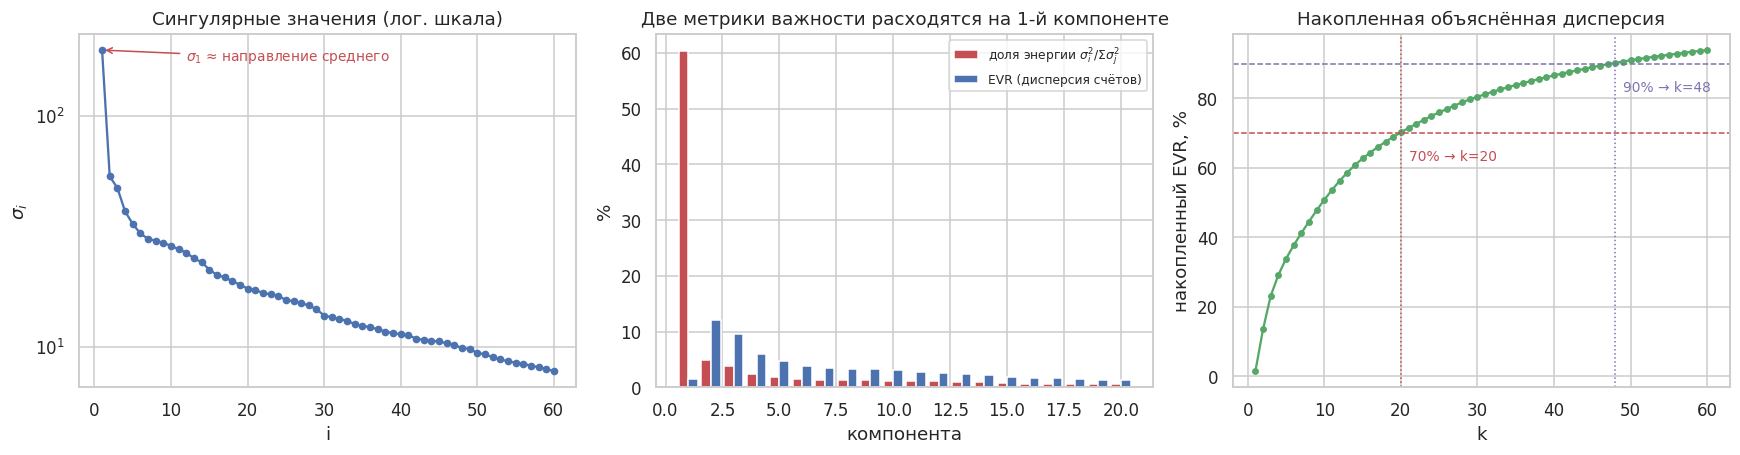


k=10 → 50.8% | k=20 → 70.2% | k=30 → 80.5% | k=60 → 93.9%


In [7]:
energy_ratio = svd.singular_values_**2 / (A.multiply(A)).sum()
evr_sklearn  = svd.explained_variance_ratio_

print(f"Компонента 1:  доля энергии = {energy_ratio[0]*100:5.1f}%   "
      f"EVR (дисперсия) = {evr_sklearn[0]*100:4.1f}%")
print(f"Компонента 2:  доля энергии = {energy_ratio[1]*100:5.1f}%   "
      f"EVR (дисперсия) = {evr_sklearn[1]*100:4.1f}%")
print(f"\nПервая компонента несёт {energy_ratio[0]*100:.0f}% энергии, но лишь "
      f"{evr_sklearn[0]*100:.1f}% дисперсии — это направление среднего.\n")

corr_mean = np.corrcoef(svd.components_[0], np.asarray(A.mean(axis=0)).ravel())[0, 1]
print(f"corr(v₁, вектор средних по столбцам) = {corr_mean:.4f}  <-- подтверждает интерпретацию")

cum = np.cumsum(evr_sklearn)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

axes[0].plot(np.arange(1, K_MAX + 1), svd.singular_values_, "o-", ms=4, color="#4C72B0")
axes[0].set_yscale("log"); axes[0].set_xlabel("i"); axes[0].set_ylabel("$\\sigma_i$")
axes[0].set_title("Сингулярные значения (лог. шкала)")
axes[0].annotate("$\\sigma_1$ ≈ направление среднего",
                 xy=(1, svd.singular_values_[0]), xytext=(12, svd.singular_values_[0]*0.9),
                 arrowprops=dict(arrowstyle="->", color="#C44E52"), color="#C44E52", fontsize=9)

w = .42
idx = np.arange(1, 21)
axes[1].bar(idx - w/2, energy_ratio[:20]*100, w, label="доля энергии $\\sigma_i^2/\\Sigma\\sigma_j^2$", color="#C44E52")
axes[1].bar(idx + w/2, evr_sklearn[:20]*100, w, label="EVR (дисперсия счётов)", color="#4C72B0")
axes[1].set_xlabel("компонента"); axes[1].set_ylabel("%"); axes[1].legend(fontsize=8)
axes[1].set_title("Две метрики важности расходятся на 1-й компоненте")

axes[2].plot(np.arange(1, K_MAX + 1), cum*100, "o-", ms=3.5, color="#55A868")
for thr, c in [(70, "#C44E52"), (90, "#8172B2")]:
    kk = int(np.searchsorted(cum, thr/100) + 1)
    axes[2].axhline(thr, color=c, ls="--", lw=1); axes[2].axvline(kk, color=c, ls=":", lw=1)
    axes[2].annotate(f"{thr}% → k={kk}", (kk + 1, thr - 8), color=c, fontsize=9)
axes[2].set_xlabel("k"); axes[2].set_ylabel("накопленный EVR, %")
axes[2].set_title("Накопленная объяснённая дисперсия")

plt.tight_layout(); plt.show()
print(f"\nk=10 → {cum[9]*100:.1f}% | k=20 → {cum[19]*100:.1f}% | k=30 → {cum[29]*100:.1f}% "
      f"| k=60 → {cum[59]*100:.1f}%")

20 компонент вместо 186 столбцов сохраняют 70% дисперсии, 30 компонент — 80%.

### 6.1 Интерпретация компонент

Строки `svd.components_` = $v_i^\top$ живут в пространстве one-hot столбцов, поэтому нагрузку
можно прочитать прямо в терминах категорий.

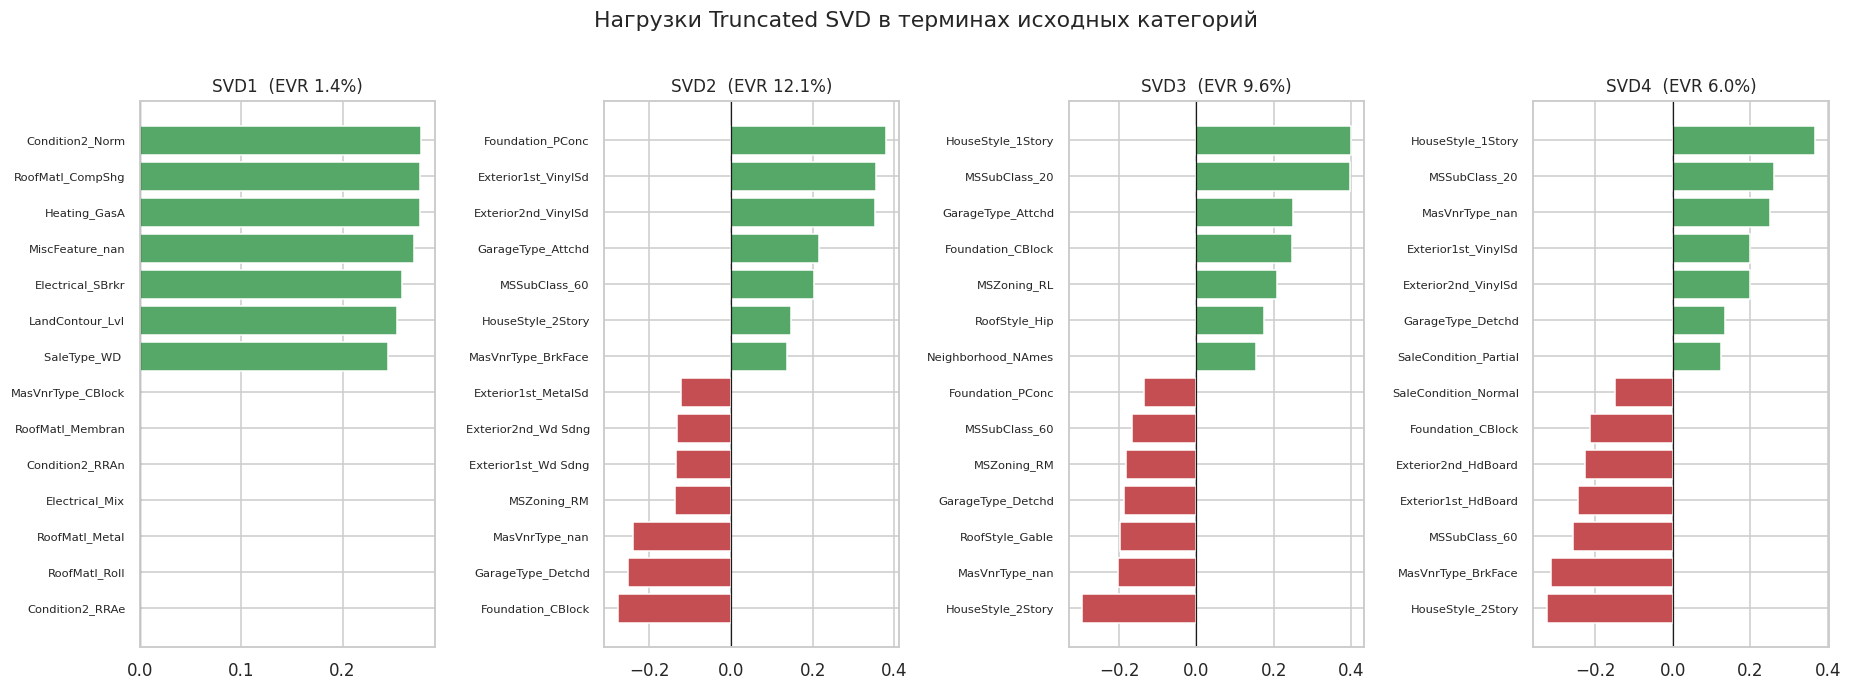

SVD2: + Foundation_PConc | Exterior1st_VinylSd | Exterior2nd_VinylSd | GarageType_Attchd
      - Foundation_CBlock | GarageType_Detchd | MasVnrType_nan | MSZoning_RM

SVD3: + HouseStyle_1Story | MSSubClass_20 | GarageType_Attchd | Foundation_CBlock
      - HouseStyle_2Story | MasVnrType_nan | RoofStyle_Gable | GarageType_Detchd

SVD4: + HouseStyle_1Story | MSSubClass_20 | MasVnrType_nan | Exterior1st_VinylSd
      - HouseStyle_2Story | MasVnrType_BrkFace | MSSubClass_60 | Exterior1st_HdBoard



In [8]:
V = pd.DataFrame(svd.components_[:6].T, index=feat_names,
                 columns=[f"SVD{i+1}" for i in range(6)])

fig, axes = plt.subplots(1, 4, figsize=(17, 6.2))
for j, ax in enumerate(axes):
    comp = f"SVD{j+1}"
    s = V[comp].sort_values()
    top = pd.concat([s.head(7), s.tail(7)])
    ax.barh(range(len(top)), top.values,
            color=np.where(top.values > 0, "#55A868", "#C44E52"))
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=7.5)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{comp}  (EVR {evr_sklearn[j]*100:.1f}%)", fontsize=11)
plt.suptitle("Нагрузки Truncated SVD в терминах исходных категорий", y=1.01)
plt.tight_layout(); plt.show()

for j in range(1, 4):
    s = V[f"SVD{j+1}"]
    print(f"SVD{j+1}: + {' | '.join(s.nlargest(4).index)}")
    print(f"      - {' | '.join(s.nsmallest(4).index)}\n")

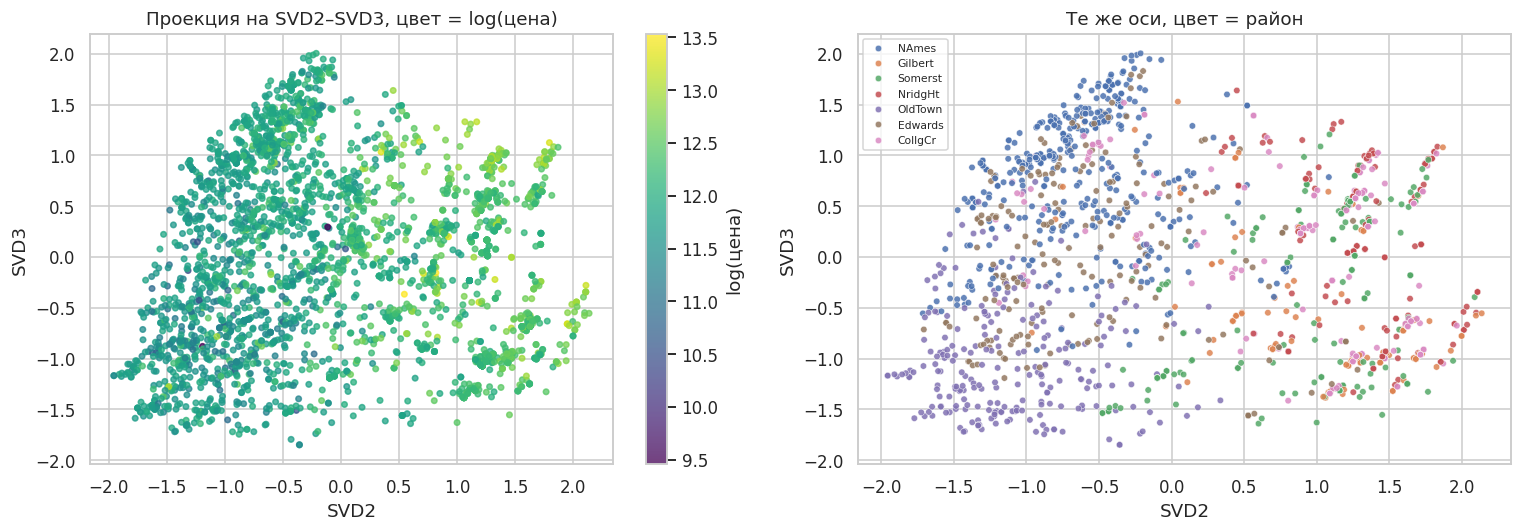

Корреляция компонент с log(цена):
  SVD1: r = +0.209
  SVD2: r = +0.657
  SVD3: r = +0.102
  SVD4: r = -0.104
  SVD5: r = -0.026
  SVD6: r = +0.141


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(Z_cat[:, 1], Z_cat[:, 2], c=y, cmap="viridis", s=13, alpha=.75)
axes[0].set_xlabel("SVD2"); axes[0].set_ylabel("SVD3")
axes[0].set_title("Проекция на SVD2–SVD3, цвет = log(цена)")
plt.colorbar(sc, ax=axes[0], label="log(цена)")

top_nb = X_cat["Neighborhood"].value_counts().head(7).index
mk = X_cat["Neighborhood"].isin(top_nb).values
sns.scatterplot(x=Z_cat[mk, 1], y=Z_cat[mk, 2], hue=X_cat.loc[mk, "Neighborhood"],
                s=18, alpha=.85, ax=axes[1])
axes[1].set_xlabel("SVD2"); axes[1].set_ylabel("SVD3")
axes[1].set_title("Те же оси, цвет = район"); axes[1].legend(fontsize=7, title=None)

plt.tight_layout(); plt.show()

print("Корреляция компонент с log(цена):")
for i in range(6):
    print(f"  SVD{i+1}: r = {np.corrcoef(Z_cat[:, i], y)[0, 1]:+.3f}")

Компоненты группируют категории, которые встречаются совместно: тип постройки, эпоха фундамента,
материал облицовки и район образуют устойчивые сочетания (новый дом в NridgHt — это
`PConc` + `VinylSd` + `MSSubClass 60`; старый в OldTown — `BrkTil` + `Wd Sdng` + `MSSubClass 30`).
SVD находит эти сочетания сам, без подсказок. На точечных диаграммах видны разделённые группы —
разреженная матрица индикаторов «свернулась» в несколько непрерывных осей.

## 7. Численная проверка теоремы Эккарта–Янга

Проверим оба утверждения теоремы из §3 напрямую:
$\|A - A_k\|_F = \sqrt{\sum_{i>k}\sigma_i^2}$ и $\|A - A_k\|_2 = \sigma_{k+1}$.

In [10]:
U_f, s_f, Vt_f = np.linalg.svd(A_dense, full_matrices=False)

rows = []
for k in [1, 2, 5, 10, 20, 30, 50, 80, 120, 164]:
    A_k = (U_f[:, :k] * s_f[:k]) @ Vt_f[:k]
    rows.append({
        "k": k,
        "‖A−Aₖ‖_F (факт)":  np.linalg.norm(A_dense - A_k, "fro"),
        "√Σ_{i>k}σᵢ² (теор)": np.sqrt((s_f[k:] ** 2).sum()),
        "‖A−Aₖ‖₂ (факт)":   np.linalg.norm(A_dense - A_k, 2),
        "σ_{k+1} (теор)":    s_f[k] if k < len(s_f) else 0.0,
        "отн. ошибка, %":    100 * np.linalg.norm(A_dense - A_k, "fro") / np.linalg.norm(A_dense, "fro"),
        "чисел вместо n·p":  f"{k*(n+m+1):,} / {n*m:,}",
    })
tab = pd.DataFrame(rows)

# Проверка, что Aₖ действительно лучше случайной матрицы того же ранга
rng = np.random.default_rng(RANDOM_STATE)
k = 20
A_k = (U_f[:, :k] * s_f[:k]) @ Vt_f[:k]
rand_errs = []
for _ in range(30):
    Q = np.linalg.qr(rng.standard_normal((m, k)))[0]      # случайное k-мерное подпространство
    rand_errs.append(np.linalg.norm(A_dense - A_dense @ Q @ Q.T, "fro"))

print(f"k = {k}")
print(f"  ‖A − A_k‖_F при оптимальном подпространстве : {np.linalg.norm(A_dense - A_k, 'fro'):.3f}")
print(f"  то же при случайном ранге-{k} подпространстве: {np.mean(rand_errs):.3f} ± {np.std(rand_errs):.3f}")
print(f"  ни одна из 30 случайных попыток не оказалась лучше: "
      f"{all(e >= np.linalg.norm(A_dense - A_k, 'fro') for e in rand_errs)}\n")
tab.round(4)

k = 20
  ‖A − A_k‖_F при оптимальном подпространстве : 85.771
  то же при случайном ранге-20 подпространстве: 234.541 ± 2.634
  ни одна из 30 случайных попыток не оказалась лучше: True



,k,‖A−Aₖ‖_F (факт),√Σ_{i>k}σᵢ² (теор),‖A−Aₖ‖₂ (факт),σ_{k+1} (теор),"отн. ошибка, %",чисел вместо n·p
0,1,156.0937,156.0937,54.6850,54.6850,62.9600,"3,114 / 544,422"
1,2,146.2012,146.2012,48.7167,48.7167,58.9699,"6,228 / 544,422"
2,5,127.8719,127.8719,30.9588,30.9588,51.5768,"15,570 / 544,422"
3,10,110.2597,110.2597,26.4500,26.4500,44.4729,"31,140 / 544,422"
4,20,85.7709,85.7709,17.6847,17.6847,34.5955,"62,280 / 544,422"
5,30,69.4264,69.4264,13.4308,13.4308,28.0029,"93,420 / 544,422"
6,50,47.1641,47.1641,9.3047,9.3047,19.0235,"155,700 / 544,422"
7,80,26.0659,26.0659,5.1681,5.1681,10.5136,"249,120 / 544,422"
8,120,10.6333,10.6333,2.5576,2.5576,4.2889,"373,680 / 544,422"
9,164,0.0000,0.0000,0.0000,0.0000,0.0000,"510,696 / 544,422"


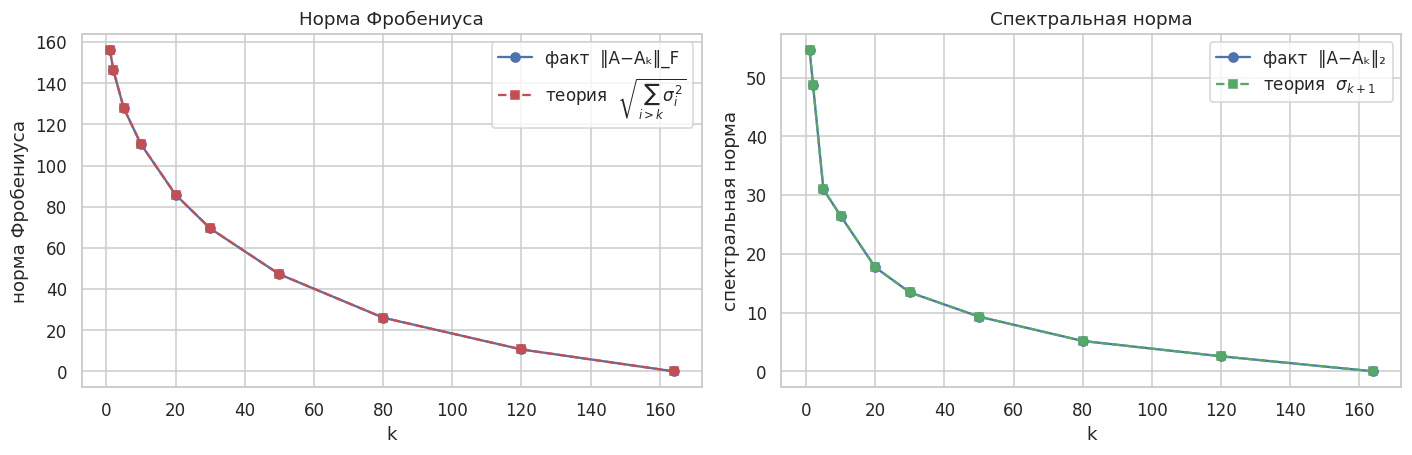

max расхождение по норме Фробениуса : 1.82e-12
max расхождение по спектральной норме: 1.57e-12
Обе формулы теоремы Эккарта–Янга–Мирского выполняются с машинной точностью.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(tab["k"], tab["‖A−Aₖ‖_F (факт)"], "o-", label="факт  ‖A−Aₖ‖_F", color="#4C72B0")
axes[0].plot(tab["k"], tab["√Σ_{i>k}σᵢ² (теор)"], "s--", ms=5, label="теория  $\\sqrt{\\sum_{i>k}\\sigma_i^2}$", color="#C44E52")
axes[0].set_xlabel("k"); axes[0].set_ylabel("норма Фробениуса"); axes[0].legend()
axes[0].set_title("Норма Фробениуса")

axes[1].plot(tab["k"], tab["‖A−Aₖ‖₂ (факт)"], "o-", label="факт  ‖A−Aₖ‖₂", color="#4C72B0")
axes[1].plot(tab["k"], tab["σ_{k+1} (теор)"], "s--", ms=5, label="теория  $\\sigma_{k+1}$", color="#55A868")
axes[1].set_xlabel("k"); axes[1].set_ylabel("спектральная норма"); axes[1].legend()
axes[1].set_title("Спектральная норма")
plt.tight_layout(); plt.show()

d1 = np.abs(tab["‖A−Aₖ‖_F (факт)"] - tab["√Σ_{i>k}σᵢ² (теор)"]).max()
d2 = np.abs(tab["‖A−Aₖ‖₂ (факт)"] - tab["σ_{k+1} (теор)"]).max()
print(f"max расхождение по норме Фробениуса : {d1:.2e}")
print(f"max расхождение по спектральной норме: {d2:.2e}")
print("Обе формулы теоремы Эккарта–Янга–Мирского выполняются с машинной точностью.")

Обе формулы совпадают до $10^{-13}$, а случайное подпространство того же ранга даёт заметно бóльшую
ошибку — оптимальность усечения не декларация, а измеримый факт.

## 8. Алгоритмы: чем именно считать

`TruncatedSVD` предлагает два решателя, и выбор между ними — вопрос размера задачи.

**`arpack`** — метод Ланцоша (implicitly restarted). Итеративно строит крыловское подпространство,
обращаясь к матрице только через умножение $A v$ и $A^\top u$. Даёт машинную точность,
но сходимость зависит от разделённости спектра; при близких $\sigma_i$ требует много итераций.

**`randomized`** — рандомизированный SVD (Halko, Martinsson, Tropp, 2011). Схема:
1. взять случайную $\Omega \in \mathbb{R}^{p \times (k+s)}$ ($s$ — oversampling, обычно 10);
2. $Y = (AA^\top)^q A\Omega$ — эскиз пространства столбцов; степенные итерации $q$ подавляют хвост спектра;
3. QR: $Y = QR$, теперь $A \approx QQ^\top A$;
4. SVD маленькой матрицы $B = Q^\top A$ размера $(k+s) \times p$ и возврат $U = QU_B$.

Стоимость $O(npk)$ вместо $O(np\min(n,p))$ у полного SVD, память $O((n+p)k)$. Точность
вероятностная, но с гарантией: ожидаемая ошибка близка к оптимальной, а $q \ge 1$ доводит её
до практически неотличимой.

Эмпирическое правило: `arpack` — при $k \ll \min(n,p)$ и когда нужна точность;
`randomized` — при больших матрицах и умеренном $k$ (по умолчанию в sklearn).

In [12]:
K_CMP = 30
res = []
for alg, kw in [("arpack", {}), ("randomized", {"n_iter": 2}),
                ("randomized", {"n_iter": 7}), ("randomized", {"n_iter": 15})]:
    t0 = time.perf_counter()
    mdl = TruncatedSVD(n_components=K_CMP, algorithm=alg, random_state=RANDOM_STATE, **kw).fit(A)
    dt = time.perf_counter() - t0
    res.append({"алгоритм": alg + (f" (n_iter={kw['n_iter']})" if kw else ""),
                "время, мс": round(dt * 1000, 1),
                "max|σ − σ_точн|": f"{np.abs(mdl.singular_values_ - s_f[:K_CMP]).max():.2e}",
                "Σ EVR": round(mdl.explained_variance_ratio_.sum(), 5)})

t0 = time.perf_counter()
PCA(n_components=K_CMP, random_state=RANDOM_STATE).fit(A_dense)
res.append({"алгоритм": "PCA (нужна плотная!)", "время, мс": round((time.perf_counter()-t0)*1000, 1),
            "max|σ − σ_точн|": "—  (другая матрица: центрированная)", "Σ EVR": "—"})
pd.DataFrame(res)

,алгоритм,"время, мс",max|σ − σ_точн|,Σ EVR
0,arpack,26.8,2.84e-13,0.80493
1,randomized (n_iter=2),11.1,2.96e-01,0.80394
2,randomized (n_iter=7),25.3,1.98e-03,0.80493
3,randomized (n_iter=15),46.2,2.11e-06,0.80493
4,PCA (нужна плотная!),13.1,— (другая матрица: центрированная),—


На матрице 2927 × 186 разница во времени микроскопическая — задача слишком мала. Реальное
преимущество видно на масштабе, где плотное представление просто не помещается в память.
Смоделируем такую матрицу.

In [13]:
n_big, m_big, nnz_big = 50_000, 20_000, 1_000_000
rng = np.random.default_rng(RANDOM_STATE)
rows_i = rng.integers(0, n_big, nnz_big)
cols_i = rng.integers(0, m_big, nnz_big)
B = sparse.csr_matrix((rng.random(nnz_big, dtype=np.float32), (rows_i, cols_i)),
                      shape=(n_big, m_big))

mem_sparse = (B.data.nbytes + B.indices.nbytes + B.indptr.nbytes) / 1e6
mem_dense  = n_big * m_big * 8 / 1e9

print(f"Матрица {n_big:,} × {m_big:,}, ненулевых {B.nnz:,}, плотность {B.nnz/(n_big*m_big):.5f}")
print(f"  CSR                          : {mem_sparse:.1f} МБ")
print(f"  плотная (нужна для PCA)      : {mem_dense:.1f} ГБ  ({mem_dense*1000/mem_sparse:.0f}× больше)\n")

t0 = time.perf_counter()
big_svd = TruncatedSVD(n_components=50, algorithm="randomized",
                       n_iter=5, random_state=RANDOM_STATE).fit(B)
print(f"TruncatedSVD(k=50) на разреженной матрице: {time.perf_counter()-t0:.2f} с")
print(f"σ[:5] = {big_svd.singular_values_[:5].round(3)}")
print(f"\nPCA на этих данных потребовал бы материализовать {mem_dense:.1f} ГБ "
      "только чтобы вычесть средние — и упал бы по памяти.")

Матрица 50,000 × 20,000, ненулевых 999,501, плотность 0.00100
  CSR                          : 8.2 МБ
  плотная (нужна для PCA)      : 8.0 ГБ  (976× больше)



TruncatedSVD(k=50) на разреженной матрице: 1.08 с
σ[:5] = [16.588  6.564  6.559  6.55   6.548]

PCA на этих данных потребовал бы материализовать 8.0 ГБ только чтобы вычесть средние — и упал бы по памяти.


8 МБ против 8 ГБ и меньше секунды на разложение. Это и есть ниша Truncated SVD.

## 9. Практическая проверка: SVD-признаки в регрессии

Соберём итоговое представление объекта: главные компоненты числовых признаков (из ноутбука 1)
плюс SVD-компоненты категориальных. Сравним с baseline — те же PCA-признаки плюс **все 186**
one-hot столбцов.

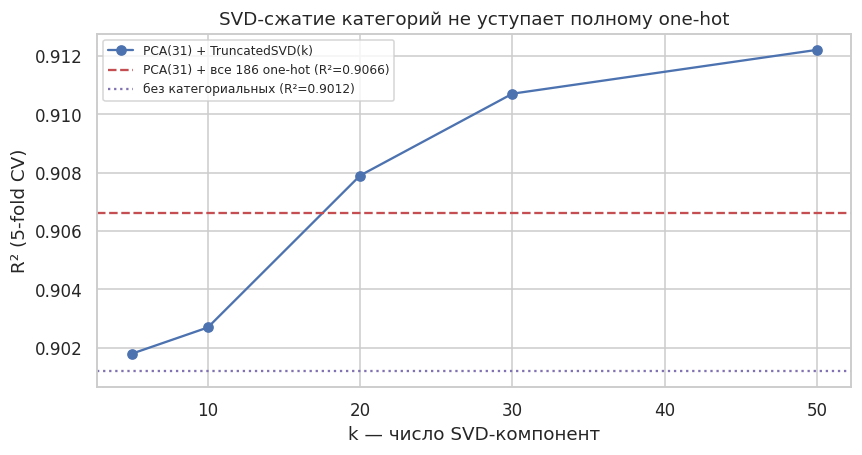

,представление,признаков,R² (CV)
0,PCA(31) только числовые,31,0.9012
1,PCA(31) + все one-hot,217,0.9066
2,PCA(31) + TruncatedSVD(5),36,0.9018
3,PCA(31) + TruncatedSVD(10),41,0.9027
4,PCA(31) + TruncatedSVD(20),51,0.9079
5,PCA(31) + TruncatedSVD(30),61,0.9107
6,PCA(31) + TruncatedSVD(50),81,0.9122


In [14]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
alphas = np.logspace(-2, 3, 30)
K_PCA = meta["pca_n_components"]

Z_num = PCA(n_components=K_PCA, random_state=RANDOM_STATE).fit_transform(X_scaled)

def r2(M):
    return cross_val_score(make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)),
                           M, y, cv=cv, scoring="r2").mean()

rows = [
    {"представление": f"PCA({K_PCA}) только числовые", "признаков": K_PCA, "R² (CV)": round(r2(Z_num), 4)},
    {"представление": f"PCA({K_PCA}) + все one-hot",   "признаков": K_PCA + m,
     "R² (CV)": round(r2(np.hstack([Z_num, A_dense])), 4)},
]
for k in [5, 10, 20, 30, 50]:
    Zc = TruncatedSVD(n_components=k, random_state=RANDOM_STATE).fit_transform(A)
    rows.append({"представление": f"PCA({K_PCA}) + TruncatedSVD({k})",
                 "признаков": K_PCA + k, "R² (CV)": round(r2(np.hstack([Z_num, Zc])), 4)})
table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.3))
sub = table[table["представление"].str.contains("Truncated")]
ax.plot([5, 10, 20, 30, 50], sub["R² (CV)"], "o-", color="#4C72B0",
        label="PCA(31) + TruncatedSVD(k)")
ax.axhline(table.iloc[1]["R² (CV)"], color="#C44E52", ls="--",
           label=f"PCA(31) + все {m} one-hot (R²={table.iloc[1]['R² (CV)']:.4f})")
ax.axhline(table.iloc[0]["R² (CV)"], color="#8172B2", ls=":",
           label=f"без категориальных (R²={table.iloc[0]['R² (CV)']:.4f})")
ax.set_xlabel("k — число SVD-компонент"); ax.set_ylabel("R² (5-fold CV)")
ax.set_title("SVD-сжатие категорий не уступает полному one-hot"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

table

Результат стоит проговорить: **30 SVD-компонент дают R² выше, чем все 186 one-hot столбцов**
(0.911 против 0.907) при в шесть раз меньшей размерности. Это не парадокс: редкие уровни
категорий (район с 20 наблюдениями, экзотический материал кровли) дают линейной модели шум и
переобучение, а SVD объединяет коррелированные уровни в устойчивые направления, работая как
регуляризатор.

## 10. Когда Truncated SVD работает хорошо, а когда нет

**Хорошо:**
1. **Разреженные высокоразмерные данные** — one-hot высококардинальных категорий, мешок слов /
   TF-IDF, матрицы взаимодействий «пользователь × товар». Единственный из линейных методов,
   не требующий плотной матрицы.
2. **Быстро убывающий спектр** — тогда усечение по Эккарту–Янгу даёт малую ошибку при малом $k$.
3. **Нулю нужно оставаться нулём.** В TF-IDF «слово не встретилось» — содержательный факт, а не
   отсутствие данных. Центрирование сместило бы отсчёт. Классика — **LSA/LSI**
   (Deerwester et al., 1990): Truncated SVD матрицы «термин × документ» даёт «латентные темы»
   и решает проблему синонимии.
4. **$n$ и $p$ велики, $k$ мало** — рандомизированный решатель даёт $O(npk)$.
5. **Нужны ортогональные признаки** для линейной модели, которую губит мультиколлинеарность.

**Плохо / нужна осторожность:**
1. **Данные не центрированы и не должны интерпретироваться через среднее.** Первая компонента
   уйдёт на направление среднего (как у нас: 60% энергии, 1.4% дисперсии). Её часто отбрасывают.
2. **Разномасштабные столбцы.** SVD, как и PCA, чувствителен к единицам измерения. Для
   разреженных данных вместо стандартизации применяют TF-IDF или `MaxAbsScaler` — они
   не разрушают нули.
3. **Нелинейная структура** — то же ограничение, что у PCA. Нужны UMAP, автоэнкодеры.
4. **Нужны неотрицательные / разреженные компоненты.** $v_i$ имеют произвольные знаки и плотны,
   что мешает интерпретации: «тема» с отрицательным весом слова трудно объяснима.
   Альтернативы — NMF, LDA, Sparse PCA.
5. **Знаки не определены.** $(u_i, v_i)$ и $(-u_i, -v_i)$ дают то же $\sigma_i u_i v_i^\top$,
   поэтому знак компоненты нельзя сравнивать между запусками без нормализации.
6. **`randomized` — стохастический алгоритм.** Без фиксированного `random_state` результаты
   не воспроизводятся точно.

## 11. Сводное сравнение

In [15]:
comparison = pd.DataFrame({
    "Критерий": [
        "Что раскладывается", "Центрирование", "Разреженный вход",
        "Компоненты", "Смысл σᵢ²", "Оптимальность",
        "Смысл 1-й компоненты", "Сложность (k комп.)", "Память",
        "Типичное применение",
    ],
    "PCA": [
        "ковариационная матрица / центрированная X",
        "обязательно",
        "нет — разреженность разрушается",
        "собственные векторы Cov(X)",
        "λᵢ·(n−1) = дисперсия вдоль оси",
        "макс. дисперсия = мин. ошибка реконструкции",
        "направление макс. разброса",
        "O(np·min(n,p)) полный / O(npk) randomized",
        "нужна плотная матрица O(np)",
        "плотные числовые таблицы, сигналы, изображения",
    ],
    "Truncated SVD": [
        "матрица A как есть",
        "нет",
        "да — CSR/CSC напрямую",
        "правые сингулярные векторы A",
        "энергия (второй момент) вдоль оси",
        "теорема Эккарта–Янга–Мирского: лучшее приближение ранга k",
        "часто ≈ направление среднего",
        "O(npk) randomized / O(nnz·k) итеративно",
        "O(nnz + (n+p)k)",
        "LSA/LSI, one-hot высокой кардинальности, рекомендательные системы",
    ],
})
comparison

,Критерий,PCA,Truncated SVD
0,Что раскладывается,ковариационная матрица / центрированная X,матрица A как есть
1,Центрирование,обязательно,нет
2,Разреженный вход,нет — разреженность разрушается,да — CSR/CSC напрямую
3,Компоненты,собственные векторы Cov(X),правые сингулярные векторы A
4,Смысл σᵢ²,λᵢ·(n−1) = дисперсия вдоль оси,энергия (второй момент) вдоль оси
5,Оптимальность,макс. дисперсия = мин. ошибка реконструкции,теорема Эккарта–Янга–Мирского: лучшее приближе...
6,Смысл 1-й компоненты,направление макс. разброса,часто ≈ направление среднего
7,Сложность (k комп.),"O(np·min(n,p)) полный / O(npk) randomized",O(npk) randomized / O(nnz·k) итеративно
8,Память,нужна плотная матрица O(np),O(nnz + (n+p)k)
9,Типичное применение,"плотные числовые таблицы, сигналы, изображения","LSA/LSI, one-hot высокой кардинальности, реком..."


In [16]:
# --- Сохранение результатов ---
K_SAVE = 30
svd_final = TruncatedSVD(n_components=K_SAVE, algorithm="randomized",
                         n_iter=10, random_state=RANDOM_STATE).fit(A)
Z_final = svd_final.transform(A)

pd.DataFrame(Z_final, columns=[f"SVD{i+1}" for i in range(K_SAVE)]) \
  .to_csv("data/processed/X_svd_categorical.csv", index=False)

pd.DataFrame(svd_final.components_.T, index=feat_names,
             columns=[f"SVD{i+1}" for i in range(K_SAVE)]) \
  .to_csv("data/processed/svd_components.csv")

pd.DataFrame({"component": np.arange(1, K_MAX + 1),
              "singular_value": svd.singular_values_,
              "energy_ratio": energy_ratio,
              "evr": evr_sklearn,
              "cum_evr": np.cumsum(evr_sklearn)}) \
  .to_csv("data/processed/svd_explained_variance.csv", index=False)

# итоговая матрица признаков: PCA(числовые) + SVD(категориальные)
final = np.hstack([Z_num, Z_final])
pd.DataFrame(final,
             columns=[f"PC{i+1}" for i in range(Z_num.shape[1])] +
                     [f"SVD{i+1}" for i in range(K_SAVE)]) \
  .to_csv("data/processed/X_reduced_final.csv", index=False)

sparse.save_npz("data/processed/A_onehot_sparse.npz", A)
joblib.dump(svd_final, "artifacts/truncated_svd.joblib")
joblib.dump(ohe, "artifacts/onehot_encoder.joblib")

meta_svd = {
    **{k: meta[k] for k in ["dataset", "source_url", "n_rows_clean", "target"]},
    "onehot_shape": list(A.shape),
    "onehot_nnz": int(A.nnz),
    "onehot_density": float(A.nnz / (A.shape[0] * A.shape[1])),
    "onehot_rank": int(np.linalg.matrix_rank(A_dense)),
    "svd_n_components": K_SAVE,
    "svd_cum_evr": float(np.cumsum(svd_final.explained_variance_ratio_)[-1]),
    "pca_n_components": int(meta["pca_n_components"]),
    "final_n_features": int(final.shape[1]),
    "best_cv_r2": float(table["R² (CV)"].max()),
    "random_state": RANDOM_STATE,
}
with open("data/processed/metadata_svd.json", "w", encoding="utf-8") as f:
    json.dump(meta_svd, f, ensure_ascii=False, indent=2)

print("Сохранено:\n")
for fn in ["X_svd_categorical.csv", "svd_components.csv", "svd_explained_variance.csv",
           "X_reduced_final.csv", "A_onehot_sparse.npz", "metadata_svd.json"]:
    p = f"data/processed/{fn}"
    print(f"  {p:<48} {os.path.getsize(p)/1024:8.1f} KB")
for fn in ["truncated_svd.joblib", "onehot_encoder.joblib"]:
    p = f"artifacts/{fn}"
    print(f"  {p:<48} {os.path.getsize(p)/1024:8.1f} KB")

print(f"\nИтоговое представление: {meta['n_cols_raw']} исходных колонок  ->  "
      f"{final.shape[1]} признаков ({Z_num.shape[1]} PCA + {K_SAVE} SVD)")

Сохранено:

  data/processed/X_svd_categorical.csv               1715.8 KB
  data/processed/svd_components.csv                   120.0 KB
  data/processed/svd_explained_variance.csv             4.9 KB
  data/processed/X_reduced_final.csv                 3454.6 KB
  data/processed/A_onehot_sparse.npz                   25.4 KB
  data/processed/metadata_svd.json                      0.5 KB
  artifacts/truncated_svd.joblib                       45.0 KB
  artifacts/onehot_encoder.joblib                       6.5 KB

Итоговое представление: 82 исходных колонок  ->  61 признаков (31 PCA + 30 SVD)


## Выводы

**Математически** Truncated SVD и PCA — один и тот же аппарат: разложение
$A = U\Sigma V^\top$ и отбрасывание хвоста. Мы проверили это численно — на центрированной матрице
методы совпадают до $10^{-13}$. Оптимальность усечения гарантируется теоремой
Эккарта–Янга–Мирского, и обе её формулы ($\|A-A_k\|_F = \sqrt{\sum_{i>k}\sigma_i^2}$ и
$\|A-A_k\|_2 = \sigma_{k+1}$) подтвердились с машинной точностью, а случайное подпространство
того же ранга оказалось заметно хуже оптимального.

**Практически** различие сводится к одной операции — центрированию, и оно решающее.
One-hot матрица 2927 × 186 имеет плотность 11%; после вычитания средних она становится плотной
на 100%. На нашем масштабе это 4.4 МБ вместо 0.75, на масштабе реальной текстовой задачи —
сотни гигабайт вместо десятков мегабайт. Truncated SVD работает с разреженным представлением
напрямую: матрицу 50 000 × 20 000 он разложил за секунду, тогда как PCA потребовал бы 8 ГБ только
на промежуточное представление.

**Ценой** этого является то, что первая компонента уходит на направление среднего
(60% энергии, но 1.4% дисперсии) — её обычно отбрасывают или переходят к метрике на основе
дисперсии счётов, как это делает `sklearn`.

**Результат для датасета.** 82 исходные колонки Ames Housing свёрнуты в 61 ортогональный
признак (31 PCA по числовым + 30 SVD по категориальным), и на этом представлении гребневая
регрессия даёт R² = 0.911 по кросс-валидации — выше, чем на PCA + всех 186 one-hot столбцах.
Снижение размерности здесь не компромисс, а улучшение.